In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [45]:
# перетворюємо в число
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# перевіряємо пропуски
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [46]:
df.dropna(subset=['TotalCharges'], inplace=True)
print(f"Залишилось рядків після очищення: {len(df)}")
df.isnull().sum()

Залишилось рядків після очищення: 7032


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

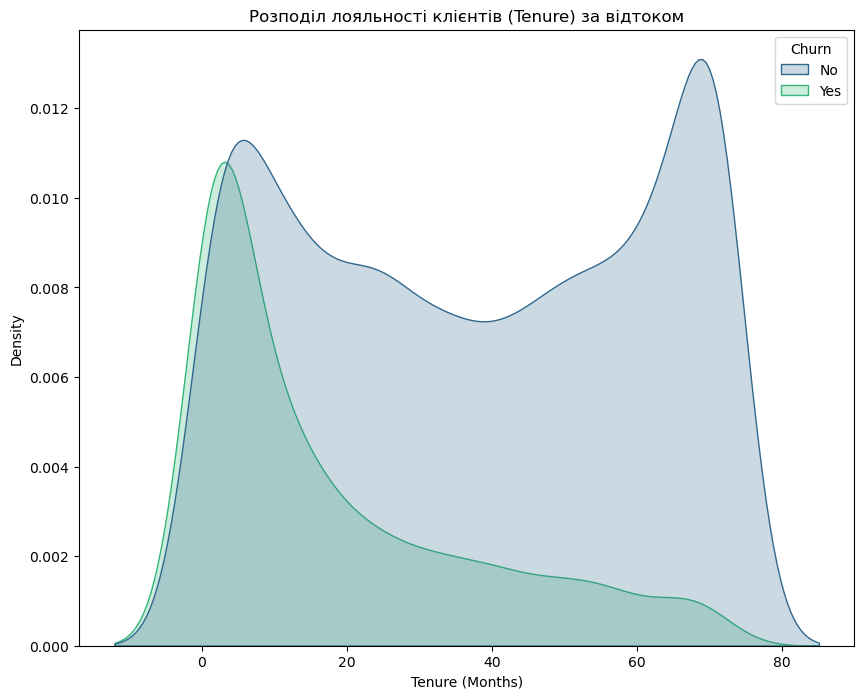

In [47]:
plt.figure(figsize=(10, 8))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='viridis')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.title('Розподіл лояльності клієнтів (Tenure) за відтоком')
plt.savefig('Customer loyalty distribution.png')
plt.show()

In [48]:
#Як бачимо на малих значеннях tenure (0–10 місяців), клієнти частіше йдуть, а на більших значеннях (30–80 місяців) частіше залишаються.

In [49]:
def get_tenure_group(tenure):
    if tenure <= 12: return '0-1 рік'
    elif tenure <= 24: return '1-2 роки'
    elif tenure <= 48: return '2-4 роки'
    else: return '4+ роки'

df['Tenure_Group'] = df['tenure'].apply(get_tenure_group)

# Перевіримо розподіл по групах
df['Tenure_Group'].value_counts()

Tenure_Group
4+ роки     2239
0-1 рік     2175
2-4 роки    1594
1-2 роки    1024
Name: count, dtype: int64

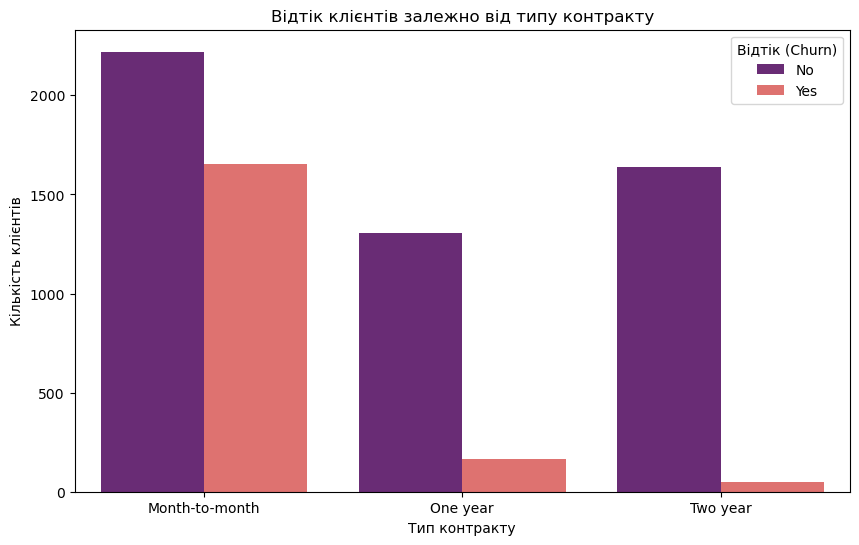

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='magma')

plt.title('Відтік клієнтів залежно від типу контракту')
plt.xlabel('Тип контракту')
plt.ylabel('Кількість клієнтів')
plt.legend(title='Відтік (Churn)')
plt.savefig('Customer churn depending on contract type.png')
plt.show()

In [51]:
#Трішки інша візуалізація, яка підключає також тип контракту.Клієнти з коротким терміном користування 
#значно частіше припиняють користування послугами, тоді як довгострокові клієнти мають вищий рівень утримання.

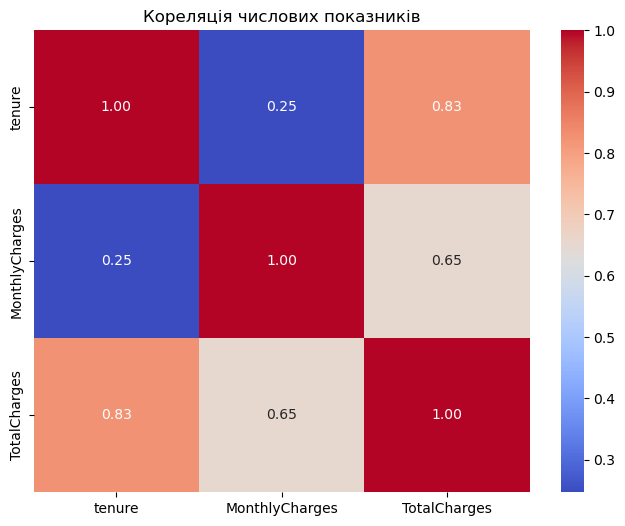

In [52]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Кореляція числових показників')
plt.savefig('Correlation.png')
plt.show()

In [53]:
#Найсильніший зв’язок спостерігається між тривалістю користування (tenure) та загальними витратами (TotalCharges), 
#що є логічним, оскільки довший період користування призводить до більших сум витрат. Інші показники мають слабший взаємозв’язок.

In [54]:
#Загальні висновки
#У ході аналізу було виявлено ключові фактори, що впливають на відтік клієнтів.
#Клієнти з коротким терміном користування (tenure) значно частіше припиняють користування послугами, 
#тоді як довгострокові клієнти мають вищий рівень утримання.

#Найвищий рівень відтоку спостерігається серед клієнтів із помісячними контрактами (month-to-month), що свідчить про низький рівень 
#їхньої прив’язаності до компанії. Натомість клієнти з довгостроковими контрактами значно рідше припиняють користування послугами.

#Також було встановлено, що вищі щомісячні витрати пов’язані з більшою ймовірністю відтоку.
#Кореляційний аналіз показав сильний зв’язок між тривалістю користування та загальними витратами, що є очікуваним результатом.

#Отримані результати можуть бути використані для розробки стратегій утримання клієнтів, 
#зокрема через стимулювання переходу на довгострокові контракти та роботу з новими клієнтами.

#Results
#The analysis identified key factors influencing customer churn.
#Customers with shorter tenure are significantly more likely to churn, while long-term customers show higher retention rates.
#The highest churn rate is observed among customers with month-to-month contracts, indicating lower commitment. 
#In contrast, customers with long-term contracts are much less likely to leave.

#Higher monthly charges are also associated with increased churn.
#Correlation analysis showed a strong relationship between tenure and total charges, which is expected.

#These insights can help businesses develop customer retention strategies, 
#such as encouraging long-term contracts and improving engagement with new customers.